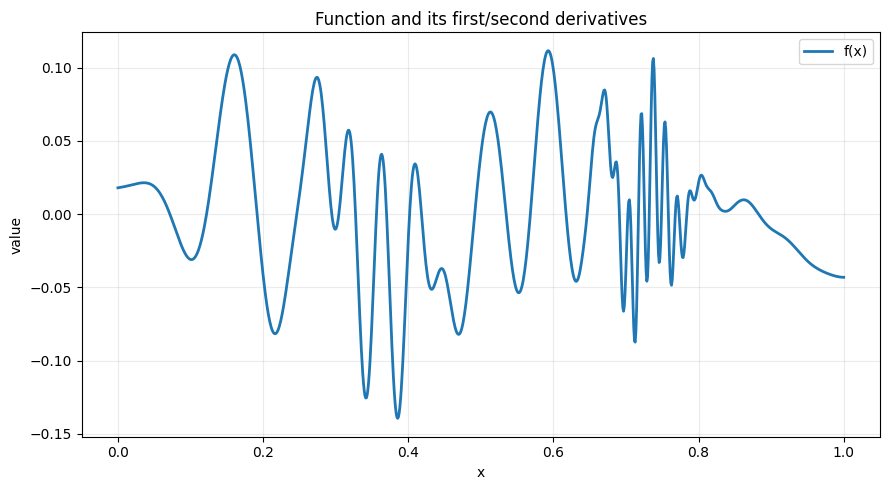

In [3]:

import torch
import matplotlib.pyplot as plt
import scipy  # (unused here; safe to remove)
from time import time

# Optional: better numerical stability
torch.set_default_dtype(torch.float64)


def _gauss(x, c, s):
    return torch.exp(-0.5*((x - c)/s)**2)

def _chirp(x, f0, f1):
    phase = 2*torch.pi*(f0*x + 0.5*(f1 - f0)*x**2)
    return torch.sin(phase)

def _val_deriv(fun, a, device, dtype):
    a = torch.tensor(a, device=device, dtype=dtype, requires_grad=True)
    y = fun(a)
    (dy,) = torch.autograd.grad(y, a, create_graph=False)
    return y.detach(), dy.detach()

def highrank_function(x, noise_std=0.0, eps=1e-12,
                      texture_gain=1.0,   # ↑ for more waviness
                      squash_range=4.0,   # targets ~[-squash_range, +squash_range]
                      squash_soft=2.0):   # smaller → stronger squash
    """
    Wavier C¹ function with same structure; constant+linear corrections keep C¹ at 0.20, 0.50, 0.80.
    Final tanh squash keeps values mostly within [-4,4] (adjust squash_range/soft to taste).
    """
    device, dtype = x.device, x.dtype

    # Global background (zero-mean-ish to avoid big drift)
    bg = (
        0.06*torch.sin(2*torch.pi*1.9*x + 0.2)
      + 0.05*torch.sin(2*torch.pi*3.7*x + 1.1)
      + 0.04*torch.cos(2*torch.pi*6.8*x + 0.7)
    )

    # ---------------- pieces (add oscillatory "texture" terms) ----------------
    def p1_fun(t):
        cusp = ((t - 0.08)**2 + eps)**(0.35)
        base = (0.28*torch.sin(6*torch.pi*t)
              + 0.25*_chirp(t, 2, 18) * _gauss(t, 0.15, 0.08)
              + 0.12*cusp
              + 0.10*(t - 0.10)**3 - 0.09*(t - 0.10)**4
              + 0.08*_gauss(t, 0.05, 0.03)*torch.sin(80*torch.pi*t))
        tex  = (
              0.18*torch.sin(120*torch.pi*t)*_gauss(t, 0.07, 0.025)
            + 0.14*torch.cos(90*torch.pi*t )*_gauss(t, 0.12, 0.05)
            + 0.08*torch.sin(2*torch.pi*11.3*t)*torch.sin(2*torch.pi*3.1*t)
        )
        return base + texture_gain*tex

    def p2_fun(t):
        rat1 =  0.10/(1.0 + ((t - 0.27)/0.015)**2)
        rat2 = -0.08/(1.0 + ((t - 0.44)/0.020)**2)
        base = (0.30*torch.cos(50*torch.pi*t) * _gauss(t, 0.30, 0.06)
              + 0.24*torch.sin(120*torch.pi*t)* _gauss(t, 0.38, 0.03)
              + rat1 + rat2
              + 0.18*_chirp(t, 14, 5) * _gauss(t, 0.46, 0.10)
              + 0.06*torch.tanh(35.0*torch.sin(18*torch.pi*t)) * _gauss(t, 0.34, 0.09))
        tex  = (
              0.22*torch.sin(180*torch.pi*t)*_gauss(t, 0.33, 0.035)
            + 0.16*torch.cos(230*torch.pi*t)*_gauss(t, 0.41, 0.028)
            + 0.10*torch.sin(2*torch.pi*7.7*t) * torch.sin(2*torch.pi*35*t)
        )
        return base + texture_gain*tex

    def p3_fun(t):
        base = (0.26*torch.sin(80*torch.pi*t) * _gauss(t, 0.66, 0.05)
              + 0.22*torch.cos(160*torch.pi*t)* _gauss(t, 0.72, 0.022)
              + 0.18*_chirp(t, 28, 8) * _gauss(t, 0.70, 0.11)
              + 0.05*torch.sin(6*torch.pi*t) * torch.sin(90*torch.pi*t) * _gauss(t, 0.62, 0.07)
              + 0.07*(t - 0.68)**2 - 0.10*(t - 0.68)**3)
        tex  = (
              0.20*torch.sin(200*torch.pi*t)*_gauss(t, 0.64, 0.030)
            + 0.18*torch.cos(260*torch.pi*t)*_gauss(t, 0.72, 0.020)
            + 0.10*torch.sin(2*torch.pi*5.5*t) * torch.sin(2*torch.pi*48*t)
        )
        return base + texture_gain*tex

    def p4_fun(t):
        cuspR = ((1.0 - t)**2 + eps)**(0.45)
        base = (0.24*torch.sin(220*torch.pi*t) * torch.exp(-60.0*(1.0 - t))
              + 0.16*torch.cos(100*torch.pi*t) * _gauss(t, 0.90, 0.03)
              + 0.12*cuspR
              + 0.05/(1.0 + ((t - 0.92)/0.015)**2)
              + 0.06*(t - 0.86)**4 - 0.08*(t - 0.86)**5)
        tex  = (
              0.18*torch.sin(300*torch.pi*t)*_gauss(t, 0.88, 0.020)
            + 0.12*torch.cos(180*torch.pi*t)*_gauss(t, 0.94, 0.018)
        )
        return base + texture_gain*tex

    a1, a2, a3 = 0.20, 0.50, 0.80
    p1 = p1_fun(x); p2 = p2_fun(x); p3 = p3_fun(x); p4 = p4_fun(x)

    # --------- C¹ corrections: match value & slope at the three joints -------
    v1, d1 = _val_deriv(p1_fun, a1, device, dtype)
    v2, d2 = _val_deriv(p2_fun, a1, device, dtype)
    c0_12, c1_12 = v1 - v2, d1 - d2
    p2_adj = p2 + c0_12 + c1_12*(x - a1)

    v2_a2, d2_a2 = _val_deriv(p2_fun, a2, device, dtype)
    vL_a2, dL_a2 = v2_a2 + c0_12 + c1_12*(a2 - a1), d2_a2 + c1_12
    v3, d3 = _val_deriv(p3_fun, a2, device, dtype)
    c0_23, c1_23 = vL_a2 - v3, dL_a2 - d3
    p3_adj = p3 + c0_23 + c1_23*(x - a2)

    v3_a3, d3_a3 = _val_deriv(p3_fun, a3, device, dtype)
    vL_a3, dL_a3 = v3_a3 + c0_23 + c1_23*(a3 - a2), d3_a3 + c1_23
    v4, d4 = _val_deriv(p4_fun, a3, device, dtype)
    c0_34, c1_34 = vL_a3 - v4, dL_a3 - d4
    p4_adj = p4 + c0_34 + c1_34*(x - a3)

    f_core = torch.where(x < a1, p1,
              torch.where(x < a2, p2_adj,
                torch.where(x < a3, p3_adj, p4_adj)))

    # Smooth extras (don’t affect joint regularity)
    series = sum((0.12/(k**1.25))*torch.sin(2*torch.pi*(1.7*k)*x + 0.3*(k % 3))
                 for k in range(1, 9))
    f0 = f_core + bg + 0.10*series

    # ---- Smooth range control to ~[-4,4] (keeps C¹, not C² at the joints) ---
    f = squash_range * torch.tanh(f0 / squash_soft)

    if noise_std > 0:
        f = f + noise_std*torch.randn_like(x)
    return f


def f_h3(x, eps=1e-12, amp=1.0):
    """
    Globally C^2 but NOT C^3, via localized (x-a)_+^3 bumps (C^2 hinges).
    With quadratic-spline interpolation on a uniform grid:
      ||f - I_h f||_{L2} = O(h^3).
    (With cubic splines you'll typically see ~h^{3.5-ε}.)
    """
    # smooth base (reuse a softened version of f_h4’s ingredients)
    base = (0.28*torch.sin(16*torch.pi*x) * _gauss(x, 0.20, 0.07)
          + 0.24*torch.cos(44*torch.pi*x) * _gauss(x, 0.36, 0.05)
          + 0.20*_chirp(x, 5, 18)         * _gauss(x, 0.58, 0.12)
          + 0.18*torch.sin(120*torch.pi*x)* _gauss(x, 0.73, 0.03))

    bg = (0.07*torch.sin(2*torch.pi*1.8*x + 0.2)
        + 0.05*torch.cos(2*torch.pi*3.3*x + 0.9))

    # C^2 “kink-of-order-3” atoms: (x-a)_+^3 * window
    def c2_bump(x, a, s, w=1.0):
        return w * torch.relu(x - a)**3 * _gauss(x, a, s)

    kinks = (
        c2_bump(x, 0.22, 0.030,  +0.8)
      + c2_bump(x, 0.37, 0.025,  -0.6)
      + c2_bump(x, 0.61, 0.035,  +0.7)
      + c2_bump(x, 0.82, 0.022,  -0.5)
    )

    # symmetric localizers to keep amplitude balanced
    pads = (
        -0.6*torch.relu(0.28 - x)**3 * _gauss(x, 0.28, 0.030)
        +0.5*torch.relu(0.42 - x)**3 * _gauss(x, 0.42, 0.028)
        -0.5*torch.relu(0.68 - x)**3 * _gauss(x, 0.68, 0.030)
        +0.4*torch.relu(0.88 - x)**3 * _gauss(x, 0.88, 0.022)
    )

    f0 = base + bg + kinks + pads
    return amp * torch.tanh(f0 / 2.5)

# Domain
x = torch.linspace(0, 1, 1000, requires_grad=True)

# f(x)
y = f_h3(x)

# f'(x)
dy_dx = torch.autograd.grad(
    outputs=y, inputs=x,
    grad_outputs=torch.ones_like(y),
    create_graph=True
)[0]

# f''(x)
d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx, inputs=x,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False
)[0]

# Plot all three
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x.detach().numpy(), y.detach().numpy(), label='f(x)', linewidth=2)
#ax.plot(x.detach().numpy(), dy_dx.detach().numpy(), label="f'(x)")
#ax.plot(x.detach().numpy(), d2y_dx2.detach().numpy(), label="f''(x)")
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.set_title('Function and its first/second derivatives')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [4]:
# 1D interpolation functions
%cd ../.. 

from src.qtt_interpolation.utils import *
from metrics.mutils import *
import numpy as np
import torchtt as tntt
import torch as tn
import teneva as ten

/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


In [5]:
def d_coeff_mat(M, order=0):
    if order == 0:
        return M
    elif order == 1:
        return M[:, 1:] * tn.tensor([1, 2, 3], dtype=M.dtype)
    elif order == 2:
        return M[:, 2:] * tn.tensor([2, 6], dtype=M.dtype)
    else:
        raise ValueError("Only derivative orders 0, 1, and 2 are supported.")
    
def qtt_I_1D(mps, fscale,f_boundary, eps = 1e-15, order = 1, p_derivative = 0,boundary = 'lineare'):

    
    ni = len(mps.N)
    nc = fscale - ni 

    sm10 = R_qtt( 2**ni -1, ni)
    sm20 = R_qtt( 2**ni -2, ni)
    smm10 = L_qtt( 1, ni)
    delta = dmps(2**ni -1,ni)

    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2

        Mkct = Mkc.t()

        Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
        O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
        delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)

    elif order == 2:

        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

        Om10 = smm10 + 3*dmpo(0,0,ni) - 3*dmpo(0,1,ni) + dmpo(0,2,ni) 
        O20 = sm20 - 3*dmpo(2**ni-1,2**ni-1,ni) + dmpo(2**ni-1,2**ni-2,ni)
        delta2 = dmps(2**ni -2,ni) + 3*dmps(2**ni -1,ni)

    
        if boundary == 'lineare':
            Om10 = smm10 + 2*dmpo(0,0,ni) - dmpo(0,1,ni) 
            O20 = sm20 - dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) + 2*dmps(2**ni -1,ni)
        elif boundary == 'mirror':
            Om10 = smm10 +  dmpo(0,1,ni) 
            O20 = sm20 + dmpo(2**ni-1,2**ni-1,ni) 
            delta2 = dmps(2**ni -2,ni) 
        elif boundary == 'clamped':
            Om10 = smm10 +  dmpo(0,0,ni) 
            O20 = sm20 
            delta2 = dmps(2**ni -2,ni) + dmps(2**ni -1,ni)
    

    corner = f_boundary*delta
    corner2 = f_boundary*delta2

    M = d_coeff_mat(Mkct, p_derivative) 
    pols = [tntt.TT(qtt_polynomial_cores(M[i], nc)) for i in range(4)]

    f_kcs = tntt.kron( ( Om10 @ mps) , pols[0] ) + tntt.kron( mps , pols[1] ) +  tntt.kron( sm10 @ mps + corner, pols[2]) +  tntt.kron( O20 @ mps + corner2 ,  pols[3])
    f_kcs = f_kcs.round(eps)

    return f_kcs

In [96]:

p_coarse = 18
p_final = 24

x0 = tn.linspace(0, 1, 2**p_coarse+1,requires_grad=True)[0:-1]
t1 = time()
y0 = f_h3(x0)



In [97]:
fc0 = tntt.TT(y0.detach(),[2]*(p_coarse),eps=1e-14)
ext = qtt_I_1D(fc0, p_final,f_h3( tn.tensor(1.0,requires_grad=False)), eps = 1e-14, order = 1, p_derivative = 0,boundary = 'linear')
dext = qtt_I_1D(fc0, p_final,f_h3( tn.tensor(1.0,requires_grad=False)), eps = 1e-14, order = 1, p_derivative = 1,boundary = 'linear')
ddext = qtt_I_1D(fc0, p_final,f_h3( tn.tensor(1.0,requires_grad=False)), eps = 1e-14, order = 2, p_derivative = 2,boundary = 'linear')

In [98]:
ddext,dd_cross

(TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, 64, 86, 80, 69, 57, 47, 41, 32, 24, 17, 10, 6, 4, 6, 6, 5, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 64070 compression 0.0038188695907592773,
 TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, 37, 39, 40, 42, 40, 40, 38, 39, 37, 35, 37, 32, 16, 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 37460 compression 0.008931159973144531)

In [99]:
Nsamples = 2**20
samples = tt_mc_sample(ext.cores,Nsamples)
ttv = ext.apply_mask(samples.T)
w = np.array([ 2**(-i-1) for i in range(p_final)])
weighted_sum = (w @ samples.numpy()).T
rv = f_h3(tn.from_numpy(weighted_sum))

(ttv-rv).norm()/np.sqrt(Nsamples)

tensor(3.3805e-13)

In [100]:
samples = tt_mc_sample(ddext.cores,Nsamples)
ttv = ddext.apply_mask(samples.T)
w = np.array([ 2**(-i-1) for i in range(p_final)])
x = tn.tensor( (w @ samples.numpy()).T, requires_grad=True, dtype=tn.float64)
rv = f_h3(x)
dy_dx = tn.autograd.grad(
outputs=rv, inputs=x,
grad_outputs=tn.ones_like(rv),
create_graph=True
)[0]
d2y_dx2 = tn.autograd.grad(
outputs=dy_dx, inputs=x,
grad_outputs=tn.ones_like(dy_dx),
create_graph=False
)[0]
(d2y_dx2-(2**(2*p_coarse))*ttv).norm().detach().numpy()/np.sqrt(Nsamples)

np.float64(0.0026358271359761577)

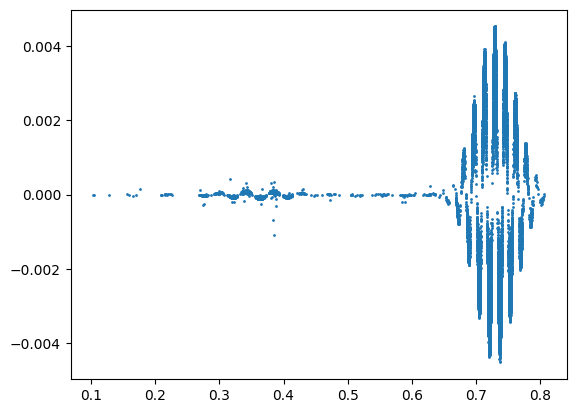

In [32]:
plt.scatter(x.detach(),d2y_dx2-2**(2*p_coarse)*ttv,s=1)

In [95]:

NN = np.sqrt(2**p_final)

x = tn.linspace(0, 1, 2**p_final+1,requires_grad=True)[0:-1]
y = f_h3(x)
dy_dx = torch.autograd.grad(
    outputs=y, inputs=x,
    grad_outputs=torch.ones_like(y),
    create_graph=True
)[0]
d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx, inputs=x,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False
)[0]


diff = (y-ext.full().flatten())
ddiff = (dy_dx-(2**p_coarse)*dext.full().flatten())
dddiff = (d2y_dx2-(2**(2*p_coarse))*ddext.full().flatten())
diff.norm()/NN, ddiff.norm()/NN, dddiff.norm()/NN


(tensor(2.5031e-15, grad_fn=<DivBackward0>),
 tensor(1.0190e-08, grad_fn=<DivBackward0>),
 tensor(0.0441))

In [36]:
d2y_dx2.norm(),x.shape[0]

(tensor(3565807.4111), 4194304)

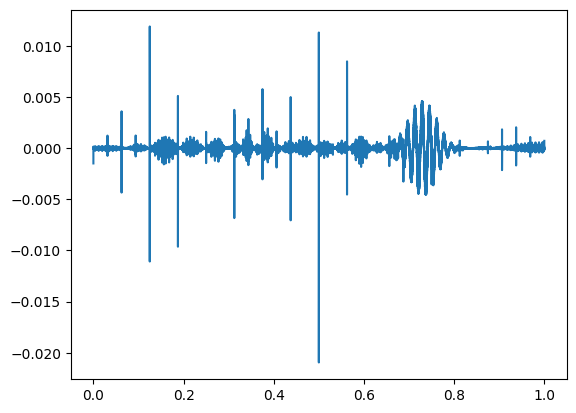

In [19]:
plt.plot(x.detach(),dddiff)

In [125]:

ttc = tntt.interpolate.function_interpolate(f_h3,tntt.TT(qtt_polynomial_cores([0,1],22)),eps=1e-14).round(1e-15)



In [43]:
p = p_final
ncoarse = [ 2]*p
m         = None  # Number of calls to target function
e         =  1e-16   # Desired accuracy
nswp      = 5   # Sweep number
r         = 20      # TT-rank of the initial tensor
dr_min    = 2      # Cross parameter (minimum number of added rows)
dr_max    = 5      # Cross parameter (maximum number of added rows)

def ften3d(I,a,b):
    X = ind_to_r_g(I,a=a,b=b,d=1,pdp=1)
    x = X[:,0]
    return f_h3( tn.tensor(x,dtype=tn.float64)).numpy()
f_wing = lambda I : ften3d(I,a=[0],b=[1])
Yc = ten.rand(ncoarse, r)
cache,info_coarse = {}, {}
ten_cross = ten.cross(f_wing, Yc, m, e, nswp, dr_min=dr_min, dr_max=dr_max,log=True,cache=cache,m_cache_scale=5,info=info_coarse)
ten_cross = ten.truncate(ten_cross, 1e-15) 

# pre | time:      0.020 | evals: 0.00e+00 (+ 0.00e+00) | rank:  20.0 | 
#   1 | time:      1.889 | evals: 1.48e+04 (+ 1.92e+04) | rank:  24.4 | e: 1.0e+00 | 
#   2 | time:      6.256 | evals: 3.20e+04 (+ 6.34e+04) | rank:  31.2 | e: 0.0e+00 | stop: e | 


In [44]:

Nsamples = 2**14
samples = tt_mc_sample([tn.from_numpy(c) for c in ten_cross],Nsamples)
ttv = tn.from_numpy( ten.act_one.get_many(ten_cross,samples.T) )
w = np.array([ 2**(-i-1) for i in range(p_final)])
weighted_sum = (w @ samples.numpy()).T
rv = f_h3(tn.from_numpy(weighted_sum))

(ttv-rv).norm()/np.sqrt(Nsamples)



tensor(7.5488e-10)

In [58]:

Dop = R_qtt( 2**p_final -1, p_final,dtype = tn.float64) - L_qtt( 1, p_final ,dtype = tn.float64) - 2*dmpo(0,0,p_final) + dmpo(0,1,p_final) +  2*dmpo(2**p_final -1,2**p_final -1,p_final) - dmpo(2**p_final -1,2**p_final -2,p_final)
Dop = (Dop*2**p_final/2).round(1e-14)
Dop

TT-matrix with sizes and ranks:
M = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 1]
Device: cpu, dtype: torch.float64
#entries 1992 compression 1.1323209037072957e-10

In [91]:
2**25

33554432

In [ ]:
d_cross = (Dop @ tntt.TT([tn.from_numpy(c) for c in ten_cross])).round(1e-14)
dd_cross = (Dop @ d_cross).round(1e-14)

Nsamples = 2**14
samples = tt_mc_sample(d_cross.cores,Nsamples)
ttv = d_cross.apply_mask(samples.T)
w = np.array([ 2**(-i-1) for i in range(p_final)])
weighted_sum = (w @ samples.numpy()).T
x = tn.tensor( (w @ samples.numpy()).T, requires_grad=True, dtype=tn.float64)
rv = f_h3(x)
dy_dx = tn.autograd.grad(
outputs=rv, inputs=x,
grad_outputs=tn.ones_like(rv),
create_graph=True
)[0]

print((ttv-dy_dx).norm()/np.sqrt(Nsamples))


samples = tt_mc_sample(dd_cross.cores,Nsamples)
ttv = dd_cross.apply_mask(samples.T)
w = np.array([ 2**(-i-1) for i in range(p_final)])
weighted_sum = (w @ samples.numpy()).T
x = tn.tensor( (w @ samples.numpy()).T, requires_grad=True, dtype=tn.float64)
rv = f_h3(x)
dy_dx = tn.autograd.grad(
outputs=rv, inputs=x,
grad_outputs=tn.ones_like(rv),
create_graph=True
)[0]

d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx, inputs=x,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False
)[0]

print((ttv-d2y_dx2).norm()/np.sqrt(Nsamples))


tensor(9.4554e-07, grad_fn=<DivBackward0>)
tensor(856.8964)


(-10000.0, 10000.0)

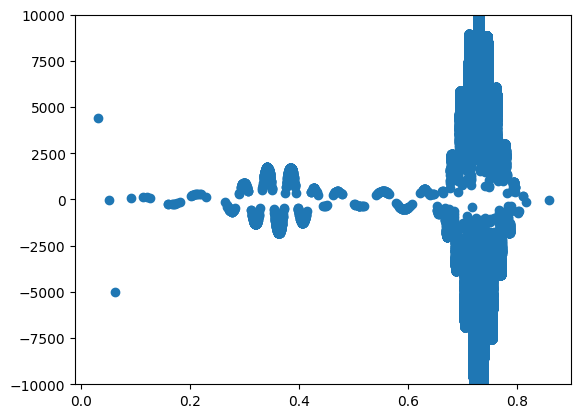

In [77]:
plt.scatter(x.detach(),ttv)
plt.ylim(-10000, 10000)

In [134]:
ycros = tntt.TT([tn.from_numpy(c) for c in ten_cross]).full().flatten()
diftenc = (y- ycros)
diftenc.norm()/y.norm()

tensor(3.8350e-11, grad_fn=<DivBackward0>)

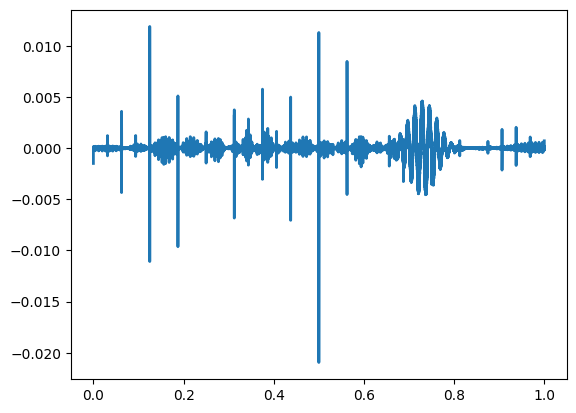

In [10]:
plt.plot(x.detach().numpy(), dddiff.detach().numpy(), label='f(x)', linewidth=2)

In [53]:
fc0, tntt.TT(dy_dx.detach(),[2]*(p_coarse),eps=1e-14)

(TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, np.int64(38), np.int64(41), np.int64(40), np.int64(39), np.int64(34), np.int64(26), np.int64(21), np.int64(18), np.int64(16), np.int64(15), np.int64(12), 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 21272 compression 0.02028656005859375,
 TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, 4, 8, 16, 32, np.int64(43), np.int64(56), np.int64(67), np.int64(77), np.int64(80), np.int64(82), np.int64(74), np.int64(55), np.int64(39), np.int64(25), np.int64(15), 8, 4, 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 79784 compression 0.07608795166015625)

In [29]:
tntt.TT(d2y_dx2.detach(),[2]*(p_coarse),eps=1e-14)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, np.int64(21), np.int64(21), np.int64(17), np.int64(15), np.int64(13), np.int64(11), np.int64(10), np.int64(9), np.int64(8), np.int64(8), np.int64(7), np.int64(6), np.int64(5), 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 4782 compression 0.0045604705810546875